# Gaussian mixture model on TS space no sampling


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import gsw
from sklearn.mixture import GaussianMixture
from funcs import profileNo_vs_xy_bins, sample_cap_bins_xy, plot_geo, plot_heatmap_npts_xy, plot_3d, cross_sec_lon, cross_sec_lon_prob

In [2]:
# Get data into dataframe
df = pd.read_csv('../../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[df_ST['year'] >= 1980] # remove the few points before 1980 (only 7 points)
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month']]

In [3]:
# Define random seed for reproducibility
seed = 22
random.seed(seed)

In [4]:
features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]']

## Distribution

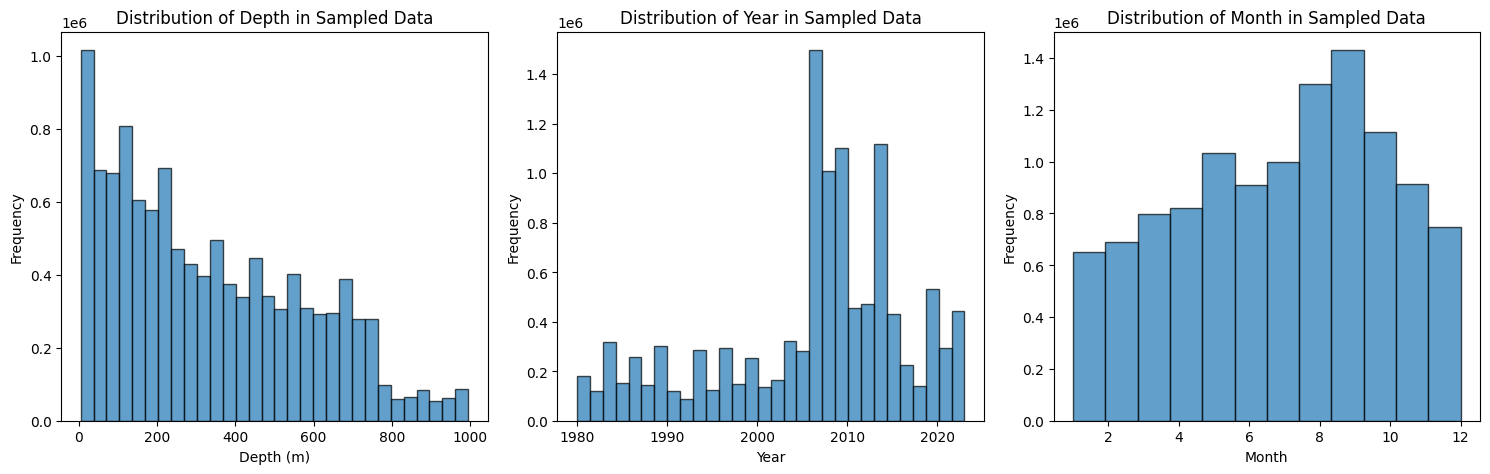

In [5]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.hist(df_ST['Depth_[m]'], bins=30, edgecolor='black', alpha=0.7) 
plt.xlabel('Depth (m)')
plt.ylabel('Frequency')
plt.title('Distribution of Depth in Sampled Data')
plt.subplot(1, 3, 2)
plt.hist(df_ST['year'], bins=30, edgecolor='black', alpha=0.7)    
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.title('Distribution of Year in Sampled Data')
plt.subplot(1, 3, 3)
plt.hist(df_ST['month'], bins=12, edgecolor='black', alpha=0.7)
plt.xlabel('Month')
plt.ylabel('Frequency')
plt.title('Distribution of Month in Sampled Data')
plt.tight_layout()
plt.show()

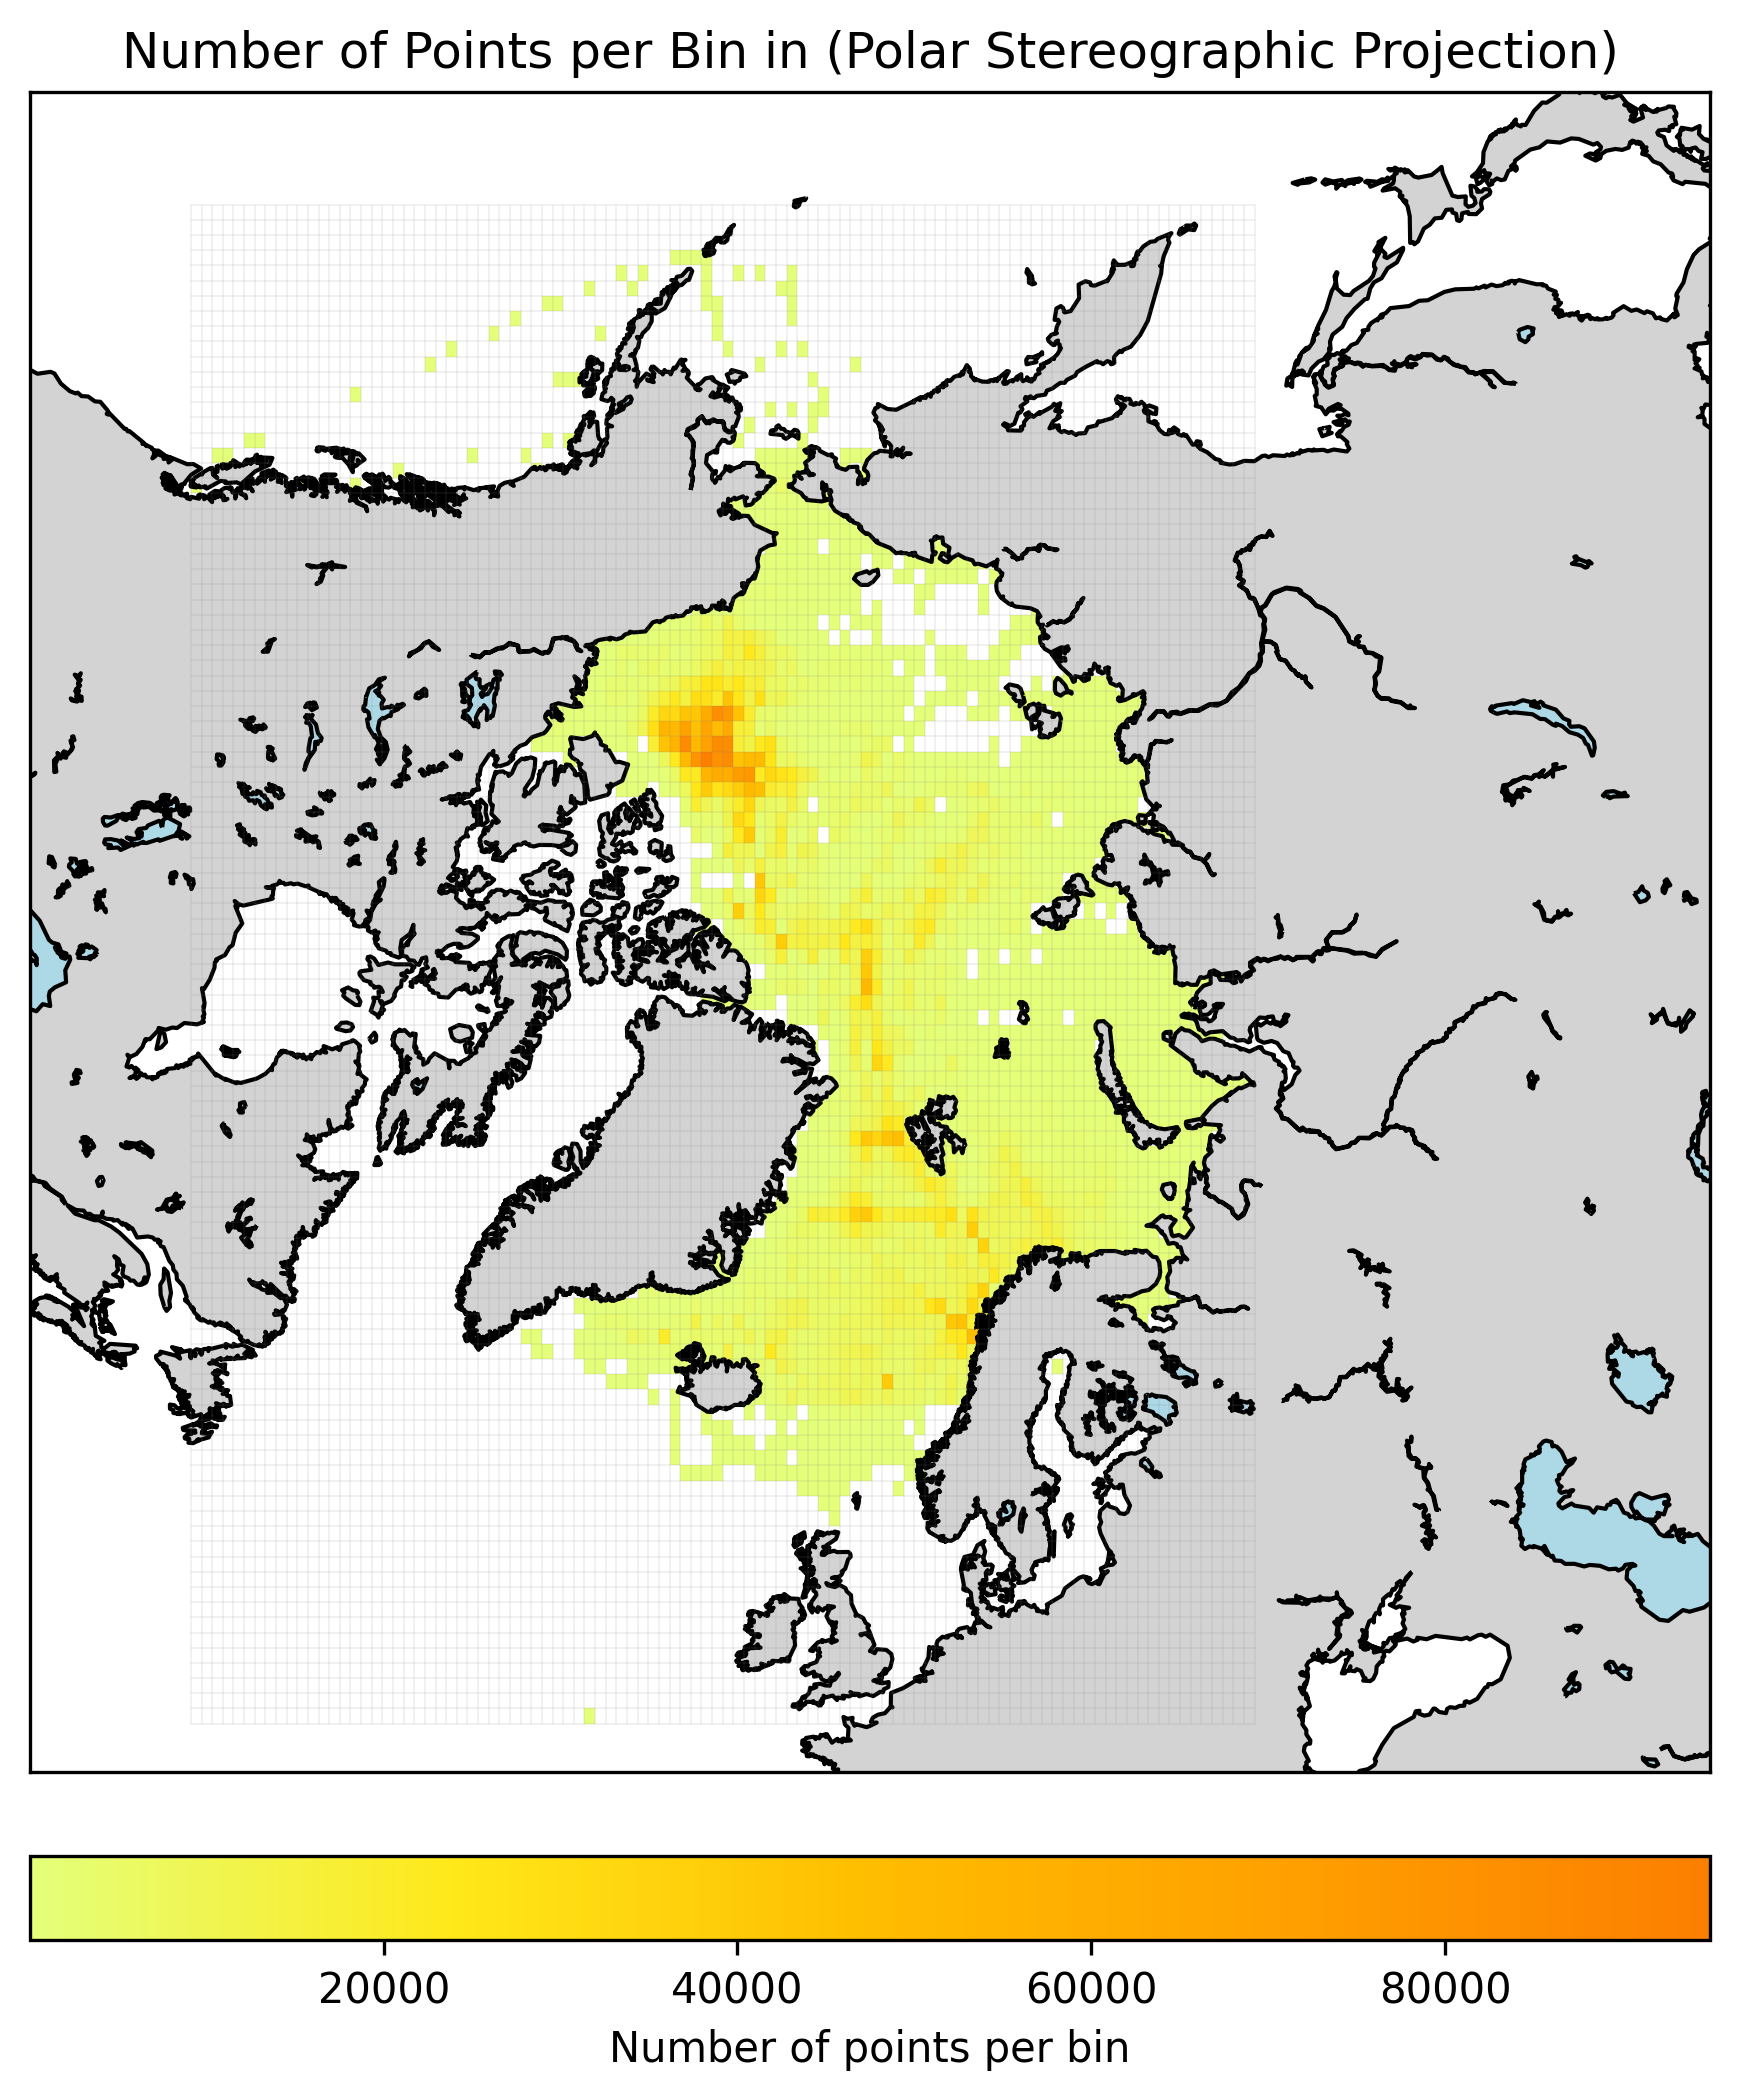

In [6]:
plot_heatmap_npts_xy(df_ST, n_x_bins=100, n_y_bins=100, projection='npstere', projection_name='Polar Stereographic')

## Four clusters to compare methods

In [7]:
# Four clusters for comparison of methods
n_clusters = 4

In [8]:
gmm = GaussianMixture(
    n_components=n_clusters,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(df_ST[features])

In [9]:
df_ST['gmm_label_4'] = labels

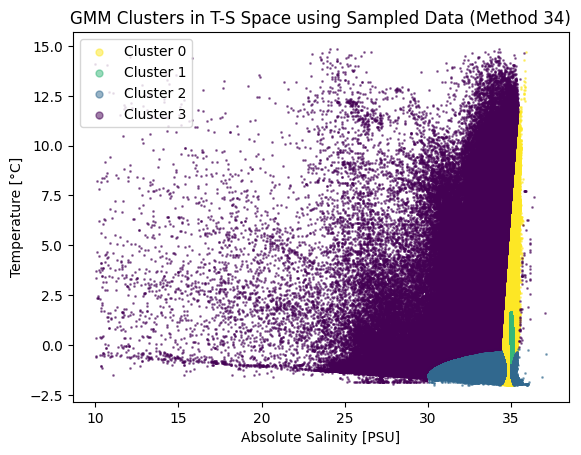

In [10]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    mask = df_ST['gmm_label_4'] == i
    plt.scatter(
        df_ST.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_ST.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 34)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

In [11]:
# Sample geographically for better plotting
df_sampled_plot = df_ST.sample(n=70000, random_state=seed)
plot_geo(df_sampled_plot, n_clusters=4)

In [12]:
# Plot in 3D
plot_3d(n_clusters,df_sampled_plot)

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Paper1/TS_again/funcs.py:625: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



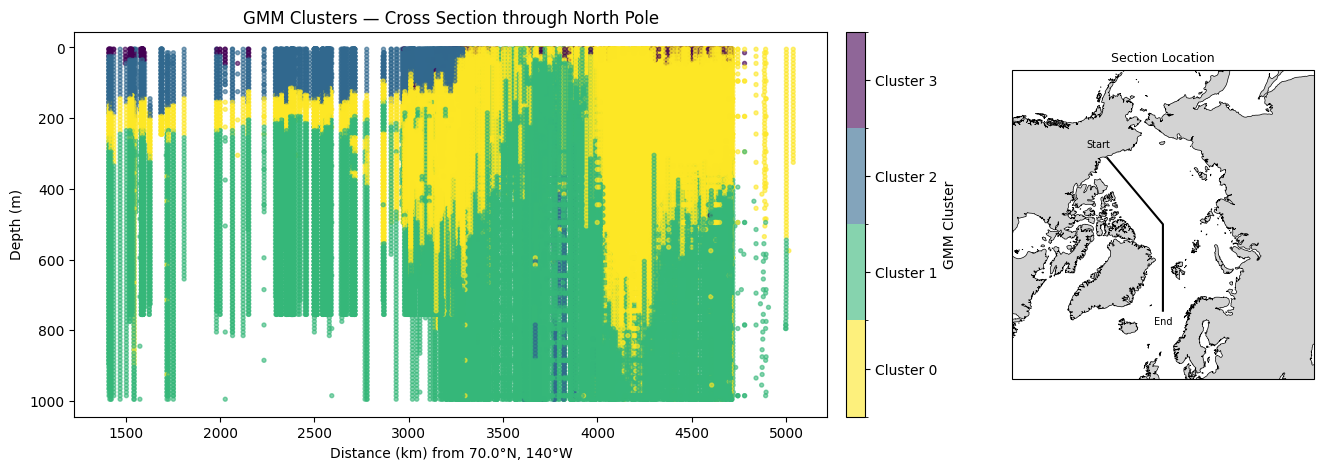

In [13]:
cross_sec_lon(df_ST, n_clusters, -180, tol=0.5, start_lat=70.0, start_lon=-140)

In [14]:
for i in range(n_clusters):
    df_ST['prob_cluster_'+str(i)] = gmm.predict_proba(df_ST[features])[:, i]

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Paper1/TS_again/funcs.py:717: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



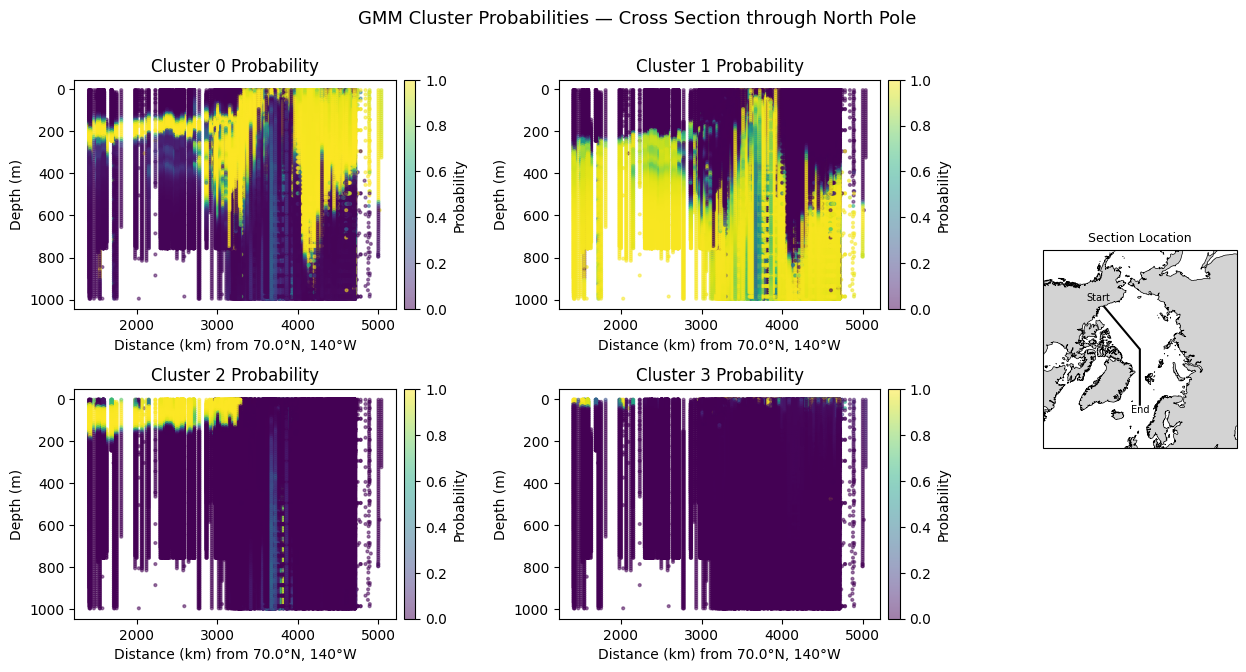

In [15]:
cross_sec_lon_prob(df_ST, -180, tol=0.5, start_lat=70.0, start_lon=-140)